## 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle


from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression , Ridge, Lasso


## 2.Load Data

In [2]:
DATA_PATH = "/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv"
df = pd.read_csv(DATA_PATH)

In [3]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [5]:
df.shape

(2640, 12)

## 3.Data Cleaning

In [6]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

## 4.EDA 

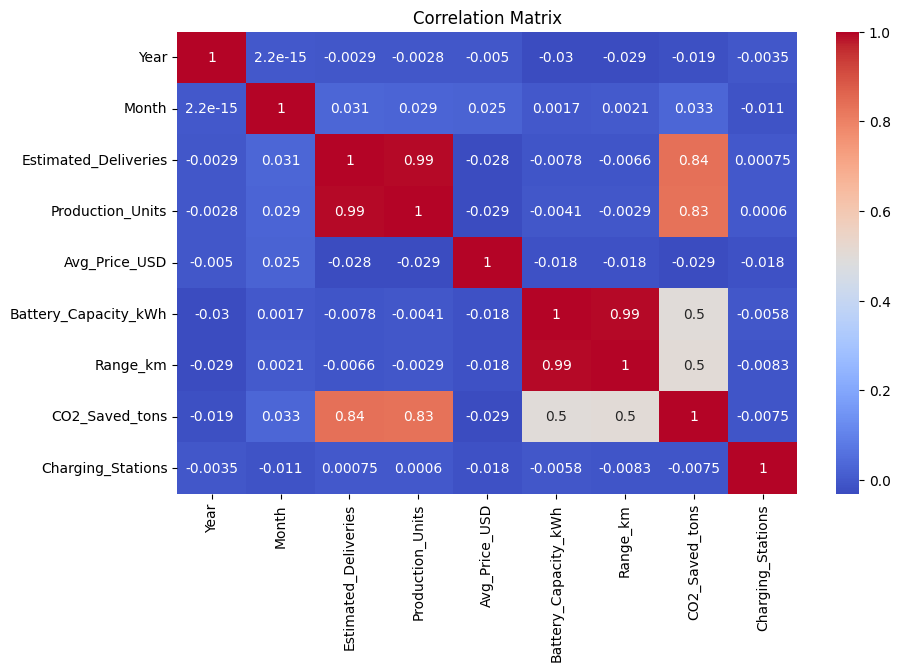

In [8]:
plt.figure(figsize = (10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(),
           annot = True,
           cmap ='coolwarm')
plt.title("Correlation Matrix")
plt.show()

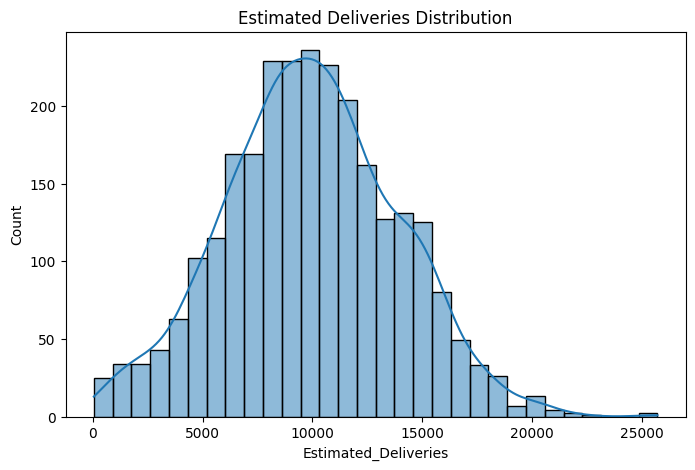

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df["Estimated_Deliveries"], bins = 30, kde =True)
plt.title("Estimated Deliveries Distribution")
plt.show()

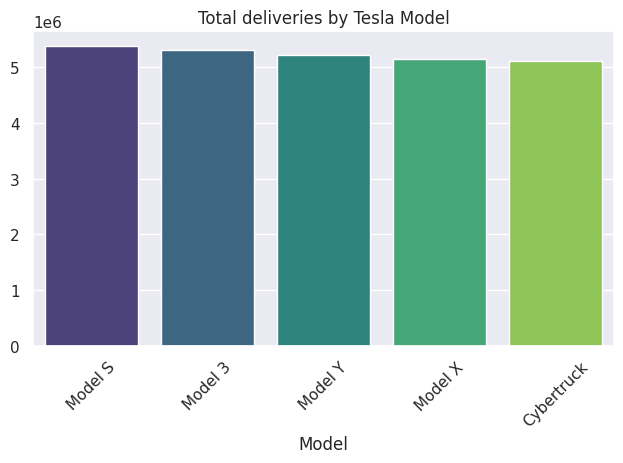

In [10]:
model_deliveries = df.groupby('Model')['Estimated_Deliveries'].sum().sort_values(ascending = False)

sns.set_theme(style="darkgrid")
sns.barplot(x=model_deliveries.index, y=model_deliveries.values, palette='viridis')
plt.title('Total deliveries by Tesla Model')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()



## 5.Feature Engineering

In [11]:
df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" +
    df["Month"].astype(str) + "-01"
)


df["Delivery_Efficiency"] = (
    df["Estimated_Deliveries"] /
    df["Production_Units"]
)

In [12]:
df.dropna(inplace=True)

## 6.Encoding

In [13]:
label_cols = ["Region","Model","Source_Type"]

encoder = LabelEncoder()

for col in label_cols:
    df[col] = encoder.fit_transform(df[col])

## 7.Building ML model

In [14]:
X = df.drop(
    columns=[
        "Estimated_Deliveries",
        "Date"
    ]
)

y = df["Estimated_Deliveries"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
def evaluate(name, pipeline, X_tr, X_te, y_tr, y_te):
    pipeline.fit(X_tr, y_tr)
    preds = pipeline.predict(X_te)
    r2   = r2_score(y_te, preds)
    mae  = mean_absolute_error(y_te, preds)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    print(f"{name:25s} | R²: {r2:.4f} | MAE: {mae:,.0f} | RMSE: {rmse:,.0f}")
    return pipeline, preds

pipelines = {
    'Linear Regression': Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
    'Ridge (L2)':        Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))]),
    'Lasso (L1)':        Pipeline([('scaler', StandardScaler()), ('model', Lasso(alpha=1.0, max_iter=5000))]),
}

results = {}
for name, pipe in pipelines.items():
    fitted_pipe, preds = evaluate(name, pipe, X_train, X_test, y_train, y_test)
    results[name] = (fitted_pipe, preds)
cv_pipe = Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))])


Linear Regression         | R²: 0.9984 | MAE: 109 | RMSE: 153
Ridge (L2)                | R²: 0.9984 | MAE: 109 | RMSE: 154
Lasso (L1)                | R²: 0.9984 | MAE: 108 | RMSE: 153


## 8.Cross Validation

In [16]:
cv_pipe = Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))])

scores = cross_val_score(
    cv_pipe,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("CV Scores:", scores)
print("Average CV Score:", scores.mean())

CV Scores: [0.99852211 0.99851299 0.99823849 0.99825719 0.99856356]
Average CV Score: 0.9984188669209664


In [17]:
param_grid = {'model__alpha': [0.01, 0.1, 1, 10, 50, 100, 500, 1000]}

gs_pipe = Pipeline([('scaler', StandardScaler()), ('model', Ridge())])

gs = GridSearchCV(gs_pipe, param_grid, cv=5, scoring='r2', n_jobs=-1)
gs.fit(X_train, y_train)

print(f"Best alpha:  {gs.best_params_['model__alpha']}")
print(f"Best CV R²: {gs.best_score_:.4f}")

Best alpha:  0.1
Best CV R²: 0.9984


In [18]:
tuned_preds = gs.predict(X_test)
print(f"\nTuned Ridge on Test Set:")
print(f"  R²:   {r2_score(y_test, tuned_preds):.4f}")
print(f"  MAE:  {mean_absolute_error(y_test, tuned_preds):,.0f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, tuned_preds)):,.0f}")


Tuned Ridge on Test Set:
  R²:   0.9984
  MAE:  109
  RMSE: 153


## 9.Plot - Actual vs Predicted

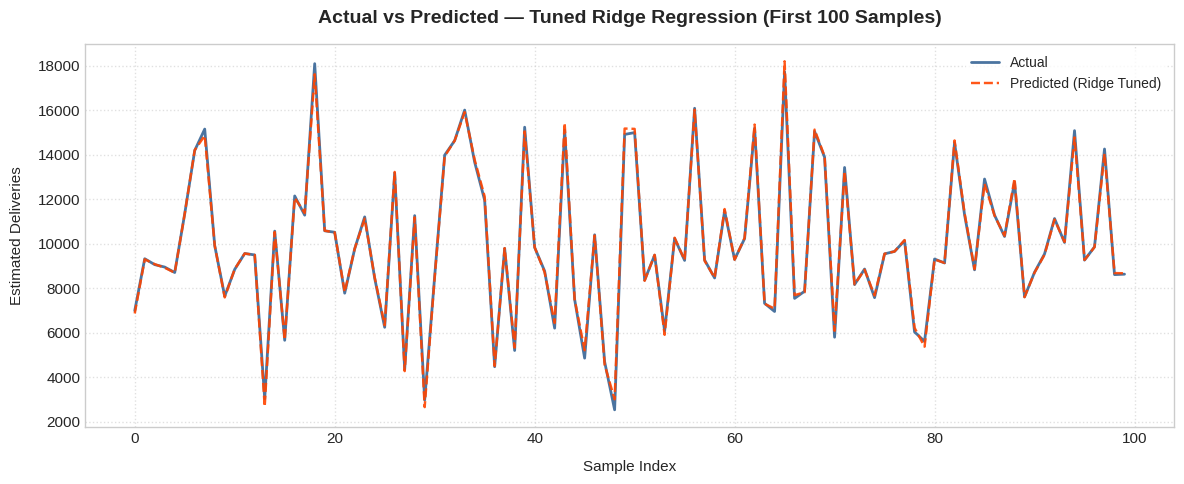

In [19]:

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 5))

plt.plot(
    y_test.values[:100], 
    label='Actual', 
    color='#2b5c8f',      
    linewidth=2.0, 
    alpha=0.85
)
plt.plot(
    tuned_preds[:100],   
    label='Predicted (Ridge Tuned)', 
    color='#ff4500',      
    linestyle='--', 
    linewidth=1.75, 
    alpha=0.9
)

plt.title('Actual vs Predicted — Tuned Ridge Regression (First 100 Samples)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Sample Index', fontsize=11, labelpad=10)
plt.ylabel('Estimated Deliveries', fontsize=11, labelpad=10)

plt.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=10, loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## 10.Save Model

In [20]:
best_model = gs.best_estimator_

with open('tesla_delivery_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("Model saved → tesla_delivery_model.pkl")

with open('tesla_delivery_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

sample = X_test.iloc[:5]
print("\nSample predictions from loaded model:")
print(loaded_model.predict(sample).round(0))

Model saved → tesla_delivery_model.pkl

Sample predictions from loaded model:
[6865. 9300. 9082. 8921. 8697.]
